In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
df = pd.read_csv("/content/sample_data/Indian Liver Patient Dataset (ILPD).csv")

print("Dataset Preview:")
print(df.head())

Dataset Preview:
   Age  Gender    TB   DB  Alkphos  Sgpt  Sopt   TP  ALB  A/G Ratio  Selector
0   65  Female   0.7  0.1      187    16    18  6.8  3.3       0.90         1
1   62    Male  10.9  5.5      699    64   100  7.5  3.2       0.74         1
2   62    Male   7.3  4.1      490    60    68  7.0  3.3       0.89         1
3   58    Male   1.0  0.4      182    14    20  6.8  3.4       1.00         1
4   72    Male   3.9  2.0      195    27    59  7.3  2.4       0.40         1


In [3]:
# Fill missing numeric values
df.fillna(df.mean(numeric_only=True), inplace=True)

# Encode Gender
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

# Convert target column
df['Selector'] = df['Selector'].replace({1:1, 2:0})

print("\nCleaned Dataset:")
print(df.head())


Cleaned Dataset:
   Age  Gender    TB   DB  Alkphos  Sgpt  Sopt   TP  ALB  A/G Ratio  Selector
0   65       0   0.7  0.1      187    16    18  6.8  3.3       0.90         1
1   62       1  10.9  5.5      699    64   100  7.5  3.2       0.74         1
2   62       1   7.3  4.1      490    60    68  7.0  3.3       0.89         1
3   58       1   1.0  0.4      182    14    20  6.8  3.4       1.00         1
4   72       1   3.9  2.0      195    27    59  7.3  2.4       0.40         1


In [6]:
X = df.drop('Selector', axis=1)
y = df['Selector']

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [9]:
model = DecisionTreeClassifier(
    criterion='gini',        # measure of impurity
    max_depth=5,             # prevents overfitting
    class_weight='balanced', # handles imbalance
    random_state=42
)

model.fit(X_train, y_train)

print("Model Training Completed")

Model Training Completed


In [10]:
y_pred = model.predict(X_test)

results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print("\nSample Predictions:")
print(results.head(10))


Sample Predictions:
   Actual  Predicted
0       0          0
1       1          1
2       1          1
3       1          1
4       1          1
5       1          0
6       0          0
7       0          0
8       0          0
9       1          0


In [11]:
print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 0.6324786324786325

Confusion Matrix:
[[30  0]
 [43 44]]

Classification Report:
              precision    recall  f1-score   support

           0       0.41      1.00      0.58        30
           1       1.00      0.51      0.67        87

    accuracy                           0.63       117
   macro avg       0.71      0.75      0.63       117
weighted avg       0.85      0.63      0.65       117



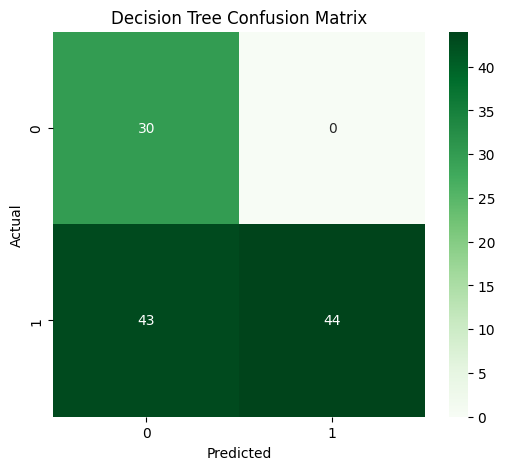

In [12]:
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")
plt.show()